# BinWaves example in Cantabria (Reconstruction)

**In this notebook**: 
<br><br>
Here waves are reconstructed in a selected grid.
<br><br>
Steps:
- Kp propagation coefficients and hindcast reconstruction is made at a grid.

In [1]:
import xarray as xr

# Load all the gridded kps and reproject

kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
kp_coeffs

<xarray.Dataset> Size: 22MB
Dimensions:   (case_num: 333, site: 11, freq: 31, dir: 24)
Coordinates:
  * case_num  (case_num) int64 3kB 0 1 2 3 4 5 6 ... 327 328 329 330 331 332 333
  * site      (site) int64 88B 1 2 3 4 5 6 7 8 9 10 11
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat       float64 8B ...
    lon       float64 8B ...
    utm_x     (site) float64 88B ...
    utm_y     (site) float64 88B ...
Data variables:
    kps       (case_num, site, freq, dir) float64 22MB ...

In [2]:
# import xarray as xr

# # Open the dataset
# ds = xr.open_dataset('outputs/jen_north_carolina_spec.nc')

# print("Dataset structure:")
# print("-----------------")
# print("\nAll variables in the dataset:")
# print("----------------------------")
# for var_name in ds.variables:
#     print(f"\nVariable: {var_name}")
#     print("Shape:", ds[var_name].shape)
#     print("First few values:", ds[var_name].values[:5] if len(ds[var_name].shape) > 0 else ds[var_name].values)
#     print("Attributes:", ds[var_name].attrs)

# print("\nDataset dimensions:")
# print("-----------------")
# for dim in ds.dims:
#     print(f"{dim}: {ds.dims[dim]}")

# print("\nDataset coordinates:")
# print("-----------------")
# for coord in ds.coords:
#     print(f"\n{coord}:")
#     print("Values:", ds[coord].values)
#     print("Attributes:", ds[coord].attrs)

# # Print the actual data variables and their dimensions
# print("\nData variables and their dimensions:")
# print("---------------------------------")
# for var in ds.data_vars:
#     print(f"\n{var}:")
#     print("Dimensions:", ds[var].dims)
#     print("Shape:", ds[var].shape)



In [ ]:
# import xarray as xr

# # Open the dataset
# ds = xr.open_dataset('outputs/jen_north_carolina_spec_utm.nc')

# print("Dataset structure:")
# print("-----------------")
# print("\nAll variables in the dataset:")
# print("----------------------------")
# for var_name in ds.variables:
#     print(f"\nVariable: {var_name}")
#     print("Shape:", ds[var_name].shape)
#     print("First few values:", ds[var_name].values[:5] if len(ds[var_name].shape) > 0 else ds[var_name].values)
#     print("Attributes:", ds[var_name].attrs)

# print("\nDataset dimensions:")
# print("-----------------")
# for dim in ds.dims:
#     print(f"{dim}: {ds.dims[dim]}")

# print("\nDataset coordinates:")
# print("-----------------")
# for coord in ds.coords:
#     print(f"\n{coord}:")
#     print("Values:", ds[coord].values)
#     print("Attributes:", ds[coord].attrs)

# # Print the actual data variables and their dimensions
# print("\nData variables and their dimensions:")
# print("---------------------------------")
# for var in ds.data_vars:
#     print(f"\n{var}:")
#     print("Dimensions:", ds[var].dims)
#     print("Shape:", ds[var].shape)

In [ ]:
# import xarray as xr
# import numpy as np
# from pyproj import Transformer

# # Open the original dataset
# ds = xr.open_dataset('outputs/jen_north_carolina_spec.nc')

# # Create a transformer from WGS84 (degrees) to UTM Zone 18N
# transformer = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)

# # Get the original coordinates (assuming they're named 'lon' and 'lat')
# lon = ds.longitude.values
# lat = ds.latitude.values

# # Convert to UTM
# utm_x, utm_y = transformer.transform(lon, lat)

# # Create a new dataset with UTM coordinates
# ds_utm = ds.copy()

# # Replace the coordinates

# ds_utm = ds_utm.assign_coords(longitude=('utm_x', utm_x))
# ds_utm = ds_utm.assign_coords(latitude=('utm_y', utm_y))

# # Add coordinate attributes
# ds_utm.utm_x.attrs = {
#     'long_name': 'UTM Easting',
#     'units': 'meters',
#     'standard_name': 'projection_x_coordinate',
#     'coordinate_system': 'UTM Zone 18N'
# }

# ds_utm.utm_y.attrs = {
#     'long_name': 'UTM Northing',
#     'units': 'meters',
#     'standard_name': 'projection_y_coordinate',
#     'coordinate_system': 'UTM Zone 18N'
# }

# # Add global attributes about the coordinate system
# ds_utm.attrs['coordinate_system'] = 'UTM Zone 18N (EPSG:32618)'
# ds_utm.attrs['original_coordinates'] = 'WGS84 (EPSG:4326)'

# # Save the new dataset
# output_file = 'jen_north_carolina_spec_utm.nc'
# ds_utm.to_netcdf(output_file)
# print(f"Created new file with UTM coordinates: {output_file}")

# # Print some information about the conversion
# print("\nCoordinate ranges:")
# print(f"Original longitude range: {lon.min():.2f} to {lon.max():.2f} degrees")
# print(f"Original latitude range: {lat.min():.2f} to {lat.max():.2f} degrees")
# print(f"UTM X range: {utm_x.min():.2f} to {utm_x.max():.2f} meters")
# print(f"UTM Y range: {utm_y.min():.2f} to {utm_y.max():.2f} meters")

In [3]:
import pandas as pd
from utils.operations import transform_ERA5_spectrum

model_parameters = pd.read_csv("NC_cases/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
# specify which range should have the spectra
offshore_spectra, offshore_spectra_case = transform_ERA5_spectrum(
    era5_spectrum=xr.open_dataset("outputs/jen_north_carolina_spec_utm.nc"),
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
)
offshore_spectra_case

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/core/accessor_dt.py:163: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  field_values = method(freq=freq).values


<xarray.DataArray 'efth' (case_num: 333, time: 405963)> Size: 541MB
array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 7.0847166e-20,
        7.2790246e-20, 6.9479947e-20],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0095968e-19,
        1.0773933e-19, 1.1075864e-19],
       ...,
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 8.0996361e-03,
        9.1488305e-03, 9.6047502e-03],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 3.1165713e-02,
        3.2662772e-02, 3.3256177e-02],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 4.2421836e-02,
        4.2826589e-02, 4.2888708e-02]], shape=(333, 405963), dtype=float32)
Coordinates:
  * case_num  (case_num) int64 3kB 0 1 2 3 4 5 6 ... 327 328 329 330 331 332 333
    station   int32 4B 133
  * time      (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01

In [4]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

# Reconstruct spectra

time_to_reconstruct = "2022-02-20"

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=time_to_reconstruct),
    kp_coeffs=kp_coeffs,
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 2MB
Dimensions:  (site: 11, freq: 31, dir: 24, time: 24)
Coordinates:
  * site     (site) int64 88B 1 2 3 4 5 6 7 8 9 10 11
  * freq     (freq) float64 248B 0.03 0.0329 0.0362 0.0397 ... 0.4145 0.4552 0.5
  * dir      (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat      float64 8B 0.0
    lon      float64 8B 0.0
    utm_x    (site) float64 88B 4.547e+05 5.047e+05 ... 5.047e+05 5.144e+05
    utm_y    (site) float64 88B 3.874e+06 3.874e+06 ... 4.074e+06 4.052e+06
    station  int32 4B 133
  * time     (time) datetime64[ns] 192B 2022-02-20 ... 2022-02-20T23:00:00
Data variables:
    kps      (time, site, freq, dir) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

(<Figure size 1500x600 with 2 Axes>, <Axes: xlabel='cx', ylabel='cy'>)

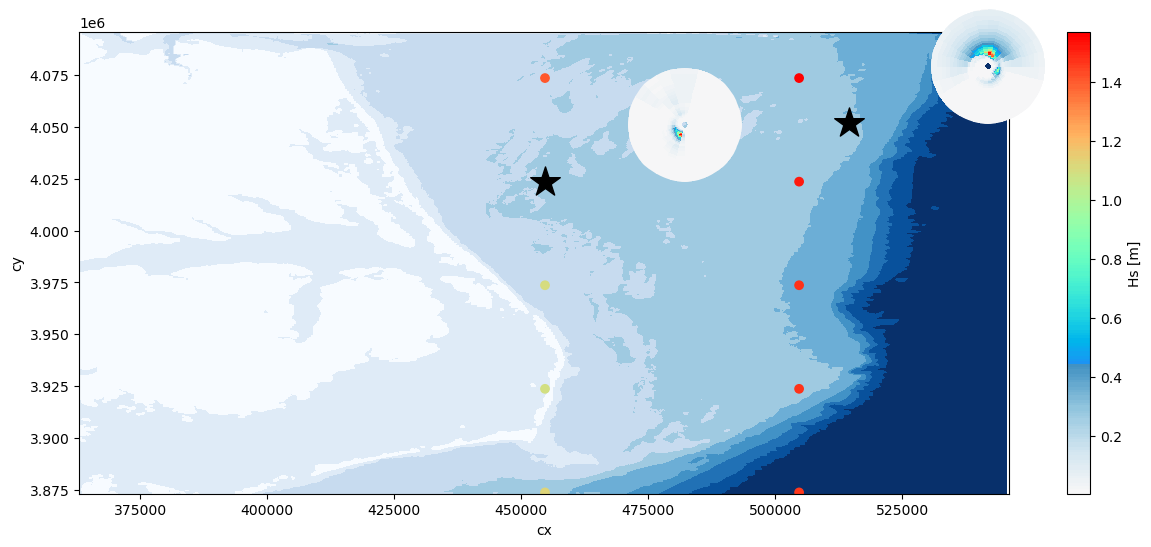

In [5]:
import xarray as xr
import matplotlib.image as mimg
from utils.plotting import plot_spectrum_in_coastline

time_to_plot = "2022-02-20 12:00"

# Plot the spectrum along the coastline
bathy = xr.open_dataset("outputs/GEBCO_NC.nc").elevation.T
# ortophoto = mimg.imread("outputs/ortophoto_cantabria.png")
plot_spectrum_in_coastline(
    bathy=bathy,
    reconstructed_onshore_spectra=reconstructed_onshore_spectra.rename({"kps": "kp"}),
    reconstruction_kps=kp_coeffs,
    offshore_spectra=offshore_spectra,
    time_to_plot=time_to_plot,
    # sites_for_spectrum=[17, 88],
    sites_for_spectrum=[6,10],
    # ortophoto=ortophoto,
)

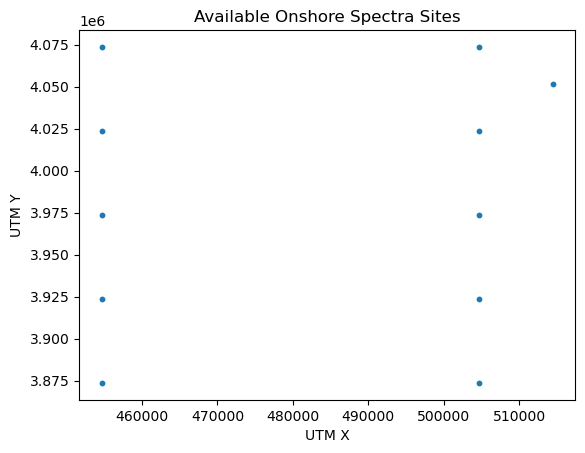

In [6]:
import matplotlib.pyplot as plt

plt.scatter(
    reconstructed_onshore_spectra.utm_x.values,
    reconstructed_onshore_spectra.utm_y.values,
    s=10
)
plt.xlabel("UTM X")
plt.ylabel("UTM Y")
plt.title("Available Onshore Spectra Sites")
plt.show()